In [12]:
import os
import wfdb
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

# ✅ Fixed seed for reproducibility
np.random.seed(42)

In [13]:
BASE_DIR      = os.path.abspath("./ecg_ssl_research/")
DATA_DIR      = os.path.join(BASE_DIR, "data", "raw", "mitdb")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(PROCESSED_DIR, exist_ok=True)

print(DATA_DIR)
print(PROCESSED_DIR)

/Applications/AI/ecg-ssl-research-final/ecg_ssl_research/data/raw/mitdb
/Applications/AI/ecg-ssl-research-final/ecg_ssl_research/data/processed


In [14]:
records = [f.split('.')[0] for f in os.listdir(DATA_DIR) if f.endswith('.dat')]
records = sorted(list(set(records)))

print(records[:10])
print("Total records:", len(records))

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']
Total records: 48


In [15]:
def process_record(record_name):
    record_path = os.path.join(DATA_DIR, record_name)

    record     = wfdb.rdrecord(record_path)
    signal     = record.p_signal          # shape: (N, 2) — both channels
    annotation = wfdb.rdann(record_path, "atr")

    valid_samples = []
    valid_labels  = []

    for i in range(len(annotation.sample)):
        sym = annotation.symbol[i]
        if sym in ['N', 'A', 'V']:
            valid_samples.append(annotation.sample[i])
            valid_labels.append(sym)

    window_size = 180
    beats  = []
    labels = []

    for i in range(len(valid_samples)):
        center = valid_samples[i]
        start  = center - window_size // 2
        end    = center + window_size // 2

        if start >= 0 and end < len(signal):
            # ✅ Use Channel 1 only (Channel 2 has artifacts in some records)
            # keeping this consistent — can switch to both later
            beat = signal[start:end, 0]
            beats.append(beat)
            labels.append(valid_labels[i])

    return beats, labels

In [16]:
all_beats  = []
all_labels = []

for record_name in tqdm(records):
    beats, labels = process_record(record_name)
    all_beats.extend(beats)
    all_labels.extend(labels)

print("Total beats:", len(all_beats))

100%|██████████| 48/48 [00:00<00:00, 58.20it/s]

Total beats: 84708


In [17]:
X = np.array(all_beats)   # shape: (N, 180)
y_str = np.array(all_labels)

label_map = {'N': 0, 'A': 1, 'V': 2}
y = np.array([label_map[l] for l in y_str])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", Counter(y))

X shape: (84708, 180)
y shape: (84708,)
Class distribution: Counter({np.int64(0): 75033, np.int64(2): 7129, np.int64(1): 2546})


In [18]:
# ✅ Normalize once here — all notebooks will use this normalized data
X = (X - X.mean(axis=1, keepdims=True)) / \
    (X.std(axis=1,  keepdims=True) + 1e-8)

print("Normalization done")
print("Mean of first sample:", X[0].mean().round(4))  # should be ~0
print("Std  of first sample:", X[0].std().round(4))   # should be ~1

Normalization done
Mean of first sample: 0.0
Std  of first sample: 1.0


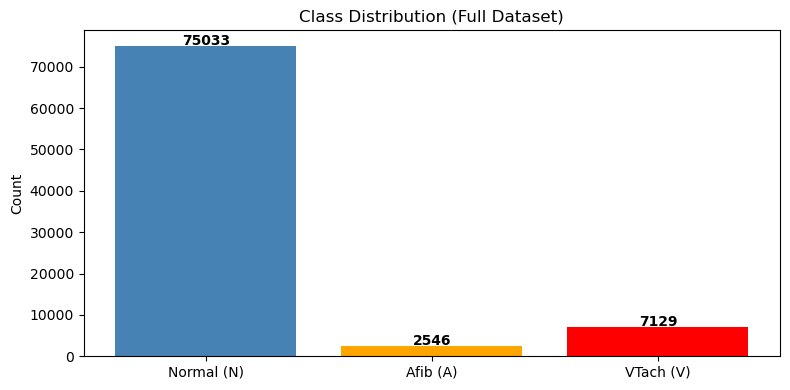

Class counts: {'Normal (N)': 75033, 'Afib (A)': 2546, 'VTach (V)': 7129}


In [19]:
counter = Counter(y)
labels  = ['Normal (N)', 'Afib (A)', 'VTach (V)']
counts  = [counter[0], counter[1], counter[2]]

plt.figure(figsize=(8, 4))
plt.bar(labels, counts, color=['steelblue', 'orange', 'red'])
plt.title("Class Distribution (Full Dataset)")
plt.ylabel("Count")
for i, c in enumerate(counts):
    plt.text(i, c + 100, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Class counts:", dict(zip(labels, counts)))

In [20]:
from sklearn.model_selection import train_test_split

# ✅ First split off test set (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Then split train into train + val (80/20 of remaining = 64/16/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f"Train size: {len(X_train)}")
print(f"Val   size: {len(X_val)}")
print(f"Test  size: {len(X_test)}")
print()
print("Train class dist:", Counter(y_train))
print("Val   class dist:", Counter(y_val))
print("Test  class dist:", Counter(y_test))

Train size: 54212
Val   size: 13554
Test  size: 16942

Train class dist: Counter({np.int64(0): 48020, np.int64(2): 4562, np.int64(1): 1630})
Val   class dist: Counter({np.int64(0): 12006, np.int64(2): 1141, np.int64(1): 407})
Test  class dist: Counter({np.int64(0): 15007, np.int64(2): 1426, np.int64(1): 509})


In [21]:
# Full dataset (for pretraining — uses all unlabeled data)
np.save(os.path.join(PROCESSED_DIR, "X.npy"), X)
np.save(os.path.join(PROCESSED_DIR, "y.npy"), y)

# Train / Val / Test splits (for fine-tuning and baseline)
np.save(os.path.join(PROCESSED_DIR, "X_train.npy"), X_train)
np.save(os.path.join(PROCESSED_DIR, "X_val.npy"),   X_val)
np.save(os.path.join(PROCESSED_DIR, "X_test.npy"),  X_test)
np.save(os.path.join(PROCESSED_DIR, "y_train.npy"), y_train)
np.save(os.path.join(PROCESSED_DIR, "y_val.npy"),   y_val)
np.save(os.path.join(PROCESSED_DIR, "y_test.npy"),  y_test)

print("✅ All splits saved to", PROCESSED_DIR)
print()
print("Files saved:")
for f in sorted(os.listdir(PROCESSED_DIR)):
    size = os.path.getsize(os.path.join(PROCESSED_DIR, f)) // 1024
    print(f"  {f:30s} {size} KB")

✅ All splits saved to /Applications/AI/ecg-ssl-research-final/ecg_ssl_research/data/processed

Files saved:
  X.npy                          119120 KB
  X_test.npy                     23824 KB
  X_train.npy                    76235 KB
  X_val.npy                      19060 KB
  y.npy                          661 KB
  y_test.npy                     132 KB
  y_train.npy                    423 KB
  y_val.npy                      106 KB


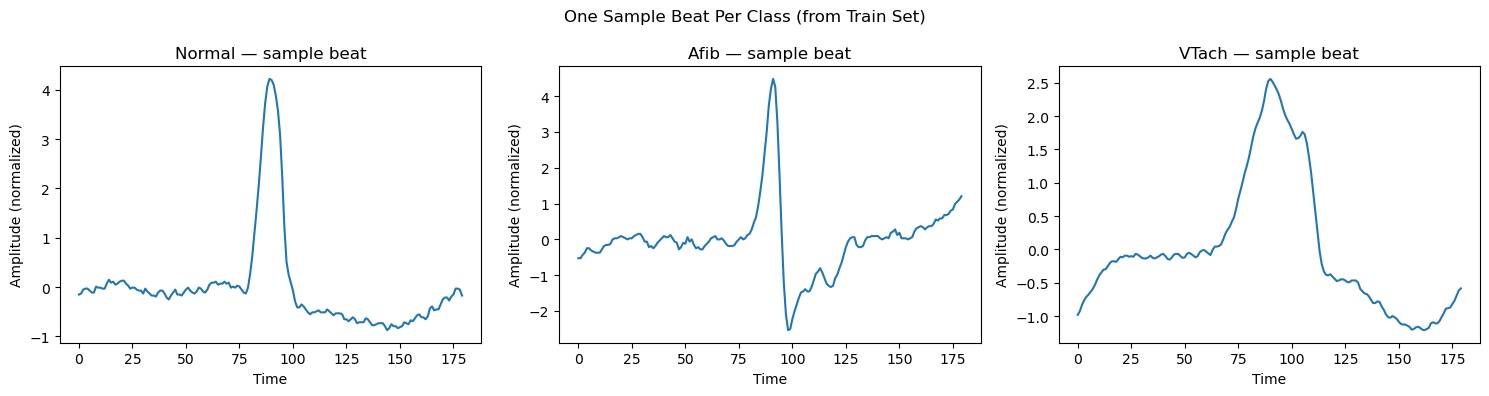

In [22]:
# Quick sanity check — plot one beat from each class from train set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = ['Normal', 'Afib', 'VTach']

for cls in range(3):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].plot(X_train[idx])
    axes[cls].set_title(f"{class_names[cls]} — sample beat")
    axes[cls].set_xlabel("Time")
    axes[cls].set_ylabel("Amplitude (normalized)")

plt.suptitle("One Sample Beat Per Class (from Train Set)")
plt.tight_layout()
plt.show()